# 02 · Embedding & clustering analysis

Load the clustered table (`clustered.parquet` = features + `umap_*` + `cluster`), visualise the latent space, quantify cluster quality with internal metrics, and profile what distinguishes each cluster.

> ⚠️ **Synthetic data.** This notebook runs on the small synthetic dataset from `scripts/make_sample_dataset.py`, so it renders and executes for anyone who clones the repo — no GPU and no private clinical data required. The *structure* of the analysis is identical to the thesis; only the numbers/figures differ. On the real MGH recordings the same cells reproduce the thesis results.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from voice_clustering.config import load_config
from voice_clustering.evaluation.metrics import score_clustering

# Plotting constants defined inline so this notebook never imports the
# headless (Agg) plotting module, which would suppress inline figures.
CLUSTER_COLORS = ['#F39C12', '#8E44AD', '#1ABC9C', '#E74C3C', '#2980B9', '#7F8C8D']
FEATURE_LABELS = {
    'zcrall': 'ZCR', 'normpeakall': 'Normalized Peak', 'spectralTiltall': 'Spectral Tilt',
    'LHratioall': 'L/H Ratio', 'level': 'Level (dB SPL)', 'cppall': 'CPP (dB)',
    'freq': 'F0 (Hz)', 'H1H2all': 'H1-H2 (dB)',
}

cfg = load_config()
features = cfg.acoustic_features
df = pd.read_parquet(cfg.paths.processed_dir / 'clustered.parquet')
umap_cols = [c for c in df.columns if c.startswith('umap_')]
print(f'{len(df):,} points · {len(umap_cols)}-D embedding')
df[['week', 'cluster', *umap_cols[:3]]].head()

32,000 points · 9-D embedding


,week,cluster,umap_0,umap_1,umap_2
0,Pre,1,1.472708,12.991857,4.460878
1,Pre,0,8.768936,0.680610,4.603591
2,Pre,1,2.876479,13.574951,4.208098
3,Pre,1,3.003207,13.497983,3.975065
4,Pre,0,7.992355,0.525490,4.929162


## Cluster sizes & noise

HDBSCAN labels low-density points as noise (`-1`). A low noise ratio and a small number of dense clusters is the signature of a clean latent structure.

In [2]:
sizes = df['cluster'].value_counts().sort_index()
noise_ratio = float((df['cluster'] == -1).mean())
n_clusters = int((sizes.index >= 0).sum())
print(f'clusters: {n_clusters} · noise ratio: {noise_ratio:.4%}')
print(sizes.rename('points'))

clusters: 3 · noise ratio: 0.0000%
cluster
0    19201
1     9586
2     3213
Name: points, dtype: int64


## Latent space (2-D view)

The pipeline embeds each window into a `9`-D UMAP space; here we scatter the first two components, coloured by the HDBSCAN label. (`visualization.py` can also fit a dedicated 2-D projection for publication figures.)

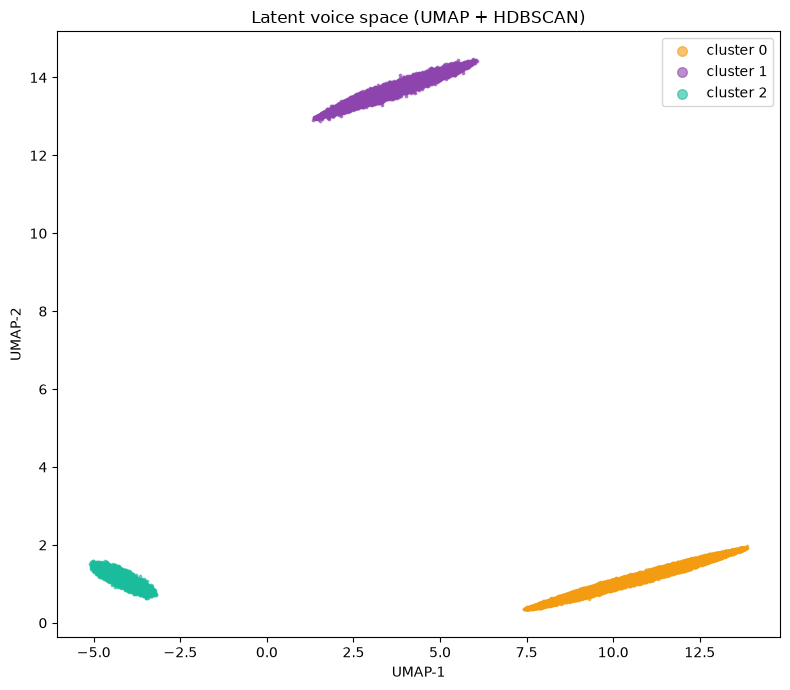

In [3]:
x, y, labels = df['umap_0'].to_numpy(), df['umap_1'].to_numpy(), df['cluster'].to_numpy()
fig, ax = plt.subplots(figsize=(8, 7))
noise = labels == -1
if noise.any():
    ax.scatter(x[noise], y[noise], s=3, c='#D5D8DC', alpha=0.4, label='noise')
for c in sorted(set(labels[~noise])):
    m = labels == c
    ax.scatter(x[m], y[m], s=3, alpha=0.6,
               c=CLUSTER_COLORS[c % len(CLUSTER_COLORS)], label=f'cluster {c}')
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
ax.set_title('Latent voice space (UMAP + HDBSCAN)')
ax.legend(markerscale=4); plt.tight_layout(); plt.show()

## Internal validity metrics

With no per-window ground truth, quality is judged with **Silhouette**, **Davies-Bouldin** and **DBCV** (density-based, appropriate for HDBSCAN's irregular clusters). Noise is excluded before scoring.

In [4]:
embedding = df[umap_cols].to_numpy(dtype=np.float64)
metrics = score_clustering(embedding, df['cluster'].to_numpy(),
                           sample_size=cfg.search.metric_sample_size, seed=cfg.seed)
pd.Series(metrics.as_dict()).to_frame('value').round(4)

,value
n_clusters,3.0000
noise_ratio,0.0000
silhouette,0.8551
davies_bouldin,0.1953
dbcv,0.9410


## What distinguishes each cluster?

Per-feature distributions across clusters reveal the acoustic signature of each phonation pattern — the basis for the clinical interpretation in the thesis (modal phonation vs singing vs anomalous-airflow).

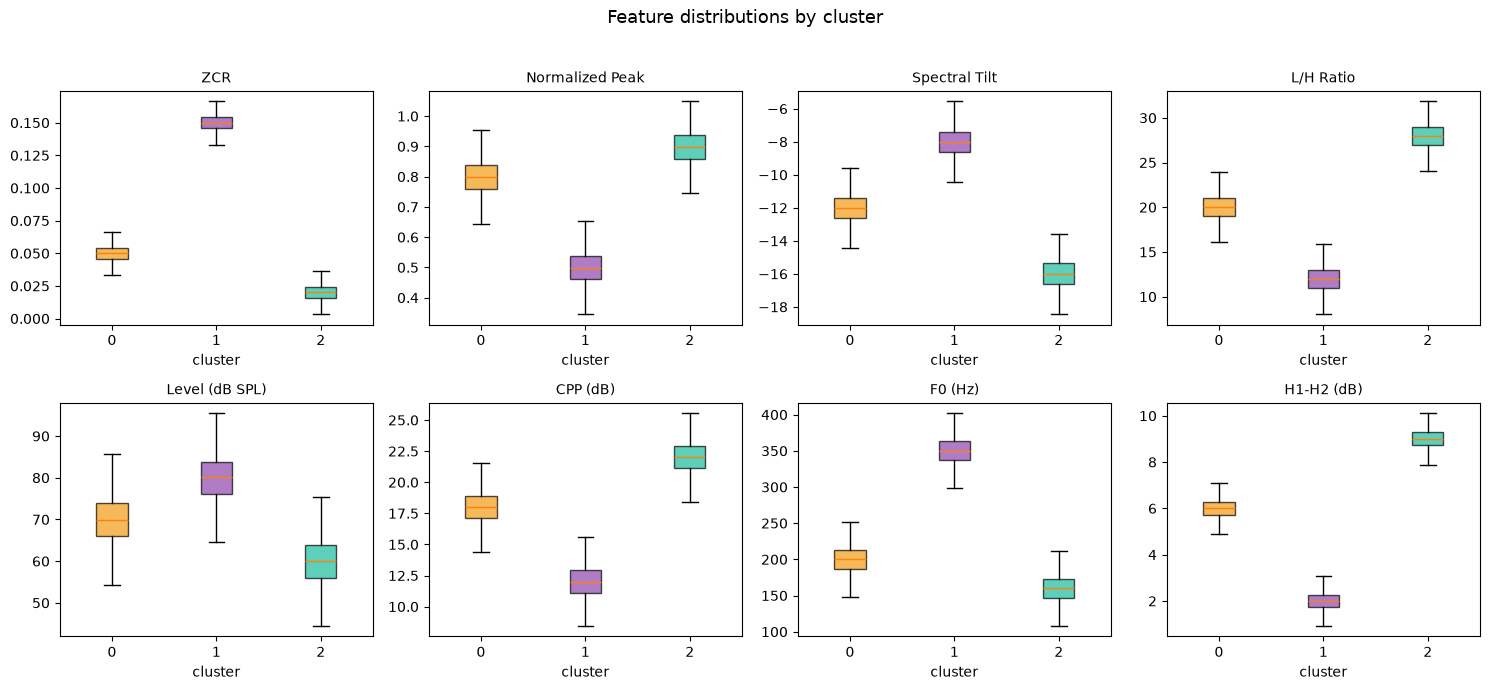

In [5]:
clusters = sorted(c for c in df['cluster'].unique() if c != -1)
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for ax, feat in zip(axes.ravel(), features):
    data = [df.loc[df['cluster'] == c, feat].to_numpy() for c in clusters]
    bp = ax.boxplot(data, patch_artist=True, showfliers=False,
                    tick_labels=[str(c) for c in clusters])
    for patch, c in zip(bp['boxes'], clusters):
        patch.set_facecolor(CLUSTER_COLORS[c % len(CLUSTER_COLORS)]); patch.set_alpha(0.7)
    ax.set_title(FEATURE_LABELS.get(feat, feat), fontsize=10); ax.set_xlabel('cluster')
fig.suptitle('Feature distributions by cluster', fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.96)); plt.show()

### Takeaways

- HDBSCAN recovers a small number of dense clusters with little noise.
- Internal metrics (DBCV / Silhouette) quantify separability without labels.
- Per-feature profiles turn each cluster into an interpretable phonation pattern — the bridge from unsupervised ML back to the clinical question.